In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns (so they don't get hidden)
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv('data/diabetic_data.csv')

# Show the first 5 rows to verify it loaded correctly
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Check the total number of rows and columns
print(f"Shape: {df.shape}")

print("\n--- Columns with '?' values ---")
# Loop through columns to count how many '?' exist in each
for col in df.columns:
    if df[col].dtype == object:
        count = df[col][df[col] == '?'].count()
        if count > 0:
            print(f"{col}: {count}")

Shape: (101766, 50)

--- Columns with '?' values ---


In [13]:
# Replace '?' with standard NaN
df = df.replace('?', np.nan)

# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100

# Filter and display only columns with missing values
missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("--- Percentage of Missing Values ---")
print(missing_data)

--- Percentage of Missing Values ---
Series([], dtype: float64)


In [14]:
# 1. Drop columns with >30% missing values
# We are dropping weight, max_glu_serum, A1Cresult, medical_specialty, and payer_code
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
df = df.drop(columns=cols_to_drop)

# 2. Drop ID columns
df = df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')

# 3. Drop any rows that still have missing values (like the 2% of rows missing 'race')
df = df.dropna()

# Check the new size of the dataset
print(f"New Shape: {df.shape}")

KeyError: "['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code'] not found in axis"

readmitted
NO     52338
>30    34649
<30    11066
Name: count, dtype: int64


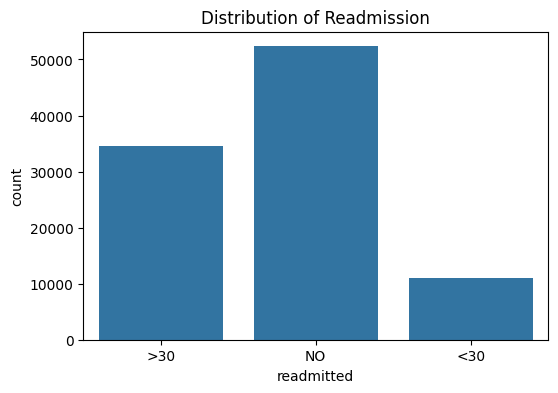

In [6]:
# Check the count of each category in the target variable
print(df['readmitted'].value_counts())

# Visualize it
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title('Distribution of Readmission')
plt.show()

readmitted
0    52338
1    45715
Name: count, dtype: int64


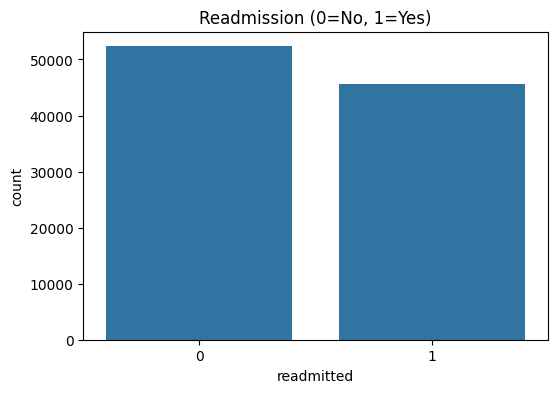

In [7]:
# Convert the target variable to binary:
# 0 = No readmission
# 1 = Readmitted (either <30 or >30)

df['readmitted'] = df['readmitted'].replace({'NO': 0, '>30': 1, '<30': 1})

# Check the new counts to ensure it worked
print(df['readmitted'].value_counts())

# Visualize the new balance
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title('Readmission (0=No, 1=Yes)')
plt.show()

In [8]:
# Select only the columns that are text (object type)
cat_cols = df.select_dtypes(include=['object']).columns

# Print how many unique values each text column has
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

race: 5 unique values
gender: 3 unique values
age: 10 unique values
diag_1: 713 unique values
diag_2: 740 unique values
diag_3: 786 unique values
metformin: 4 unique values
repaglinide: 4 unique values
nateglinide: 4 unique values
chlorpropamide: 4 unique values
glimepiride: 4 unique values
acetohexamide: 2 unique values
glipizide: 4 unique values
glyburide: 4 unique values
tolbutamide: 2 unique values
pioglitazone: 4 unique values
rosiglitazone: 4 unique values
acarbose: 4 unique values
miglitol: 4 unique values
troglitazone: 2 unique values
tolazamide: 3 unique values
examide: 1 unique values
citoglipton: 1 unique values
insulin: 4 unique values
glyburide-metformin: 4 unique values
glipizide-metformin: 2 unique values
glimepiride-pioglitazone: 2 unique values
metformin-rosiglitazone: 1 unique values
metformin-pioglitazone: 2 unique values
change: 2 unique values
diabetesMed: 2 unique values
readmitted: 2 unique values


/var/folders/v9/qx35lffs5xg9_5sb4g096g140000gn/T/ipykernel_5926/2093022232.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [9]:
# 1. Drop columns that only have 1 unique value
cols_to_drop = [col for col in df.columns if df[col].nunique() == 1]
df = df.drop(columns=cols_to_drop)
print(f"Dropped constant columns: {cols_to_drop}")

# 2. Define a function to group ICD-9 diagnosis codes
def map_diagnosis(value):
    if pd.isna(value):
        return "Other"
    
    # Handle codes starting with V or E (Supplementary codes)
    if str(value).startswith('V') or str(value).startswith('E'):
        return "Other"
    
    try:
        code = float(value)
    except:
        return "Other"
    
    # Standard ICD-9 groupings
    if 390 <= code <= 459 or code == 785:
        return 'Circulatory'
    elif 460 <= code <= 519 or code == 786:
        return 'Respiratory'
    elif 520 <= code <= 579 or code == 787:
        return 'Digestive'
    elif 250 <= code < 251:
        return 'Diabetes'
    elif 800 <= code <= 999:
        return 'Injury'
    elif 710 <= code <= 739:
        return 'Musculoskeletal'
    elif 580 <= code <= 629 or code == 788:
        return 'Genitourinary'
    elif 140 <= code <= 239:
        return 'Neoplasms' # Cancer
    else:
        return 'Other'

# 3. Apply this function to the 3 diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_diagnosis)

# Check the new simplified categories
print("\nNew diagnosis categories:")
print(df['diag_1'].value_counts())

Dropped constant columns: ['examide', 'citoglipton', 'metformin-rosiglitazone']

New diagnosis categories:
diag_1
Circulatory        29630
Other              17541
Respiratory        13993
Digestive           9187
Diabetes            7965
Injury              6703
Genitourinary       4983
Musculoskeletal     4739
Neoplasms           3312
Name: count, dtype: int64


In [10]:
# Check unique age values to see the format
print("Original Age values:", df['age'].unique())

# Create a mapping dictionary to convert text ranges to numeric midpoints
age_mapping = {
    '[0-10)': 5, 
    '[10-20)': 15, 
    '[20-30)': 25, 
    '[30-40)': 35,
    '[40-50)': 45, 
    '[50-60)': 55, 
    '[60-70)': 65, 
    '[70-80)': 75,
    '[80-90)': 85, 
    '[90-100)': 95
}

# Apply the mapping
df['age'] = df['age'].replace(age_mapping)

# Verify it is now numeric
print("New Age values:", df['age'].unique())
print(df['age'].dtype)

Original Age values: <StringArray>
[ '[10-20)',  '[20-30)',  '[30-40)',  '[40-50)',  '[50-60)',  '[60-70)',
  '[70-80)',  '[80-90)', '[90-100)',   '[0-10)']
Length: 10, dtype: str
New Age values: [15 25 35 45 55 65 75 85 95 5]
object


In [11]:
# 1. Force age to be numeric
df['age'] = df['age'].astype(int)

# 2. Convert all categorical columns (text) into numeric (dummy variables)
df_clean = pd.get_dummies(df, drop_first=True)

# Check the final shape
print(f"Original shape: {df.shape}")
print(f"New shape after encoding: {df_clean.shape}")

# Show the first few columns to see the change
df_clean.head()

Original shape: (98053, 40)
New shape after encoding: (98053, 92)


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,diag_1_Diabetes,diag_1_Digestive,diag_1_Genitourinary,diag_1_Injury,diag_1_Musculoskeletal,diag_1_Neoplasms,diag_1_Other,diag_1_Respiratory,diag_2_Diabetes,diag_2_Digestive,diag_2_Genitourinary,diag_2_Injury,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Other,diag_2_Respiratory,diag_3_Diabetes,diag_3_Digestive,diag_3_Genitourinary,diag_3_Injury,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Other,diag_3_Respiratory,metformin_No,metformin_Steady,metformin_Up,repaglinide_No,repaglinide_Steady,repaglinide_Up,nateglinide_No,nateglinide_Steady,nateglinide_Up,chlorpropamide_No,chlorpropamide_Steady,chlorpropamide_Up,glimepiride_No,glimepiride_Steady,glimepiride_Up,acetohexamide_Steady,glipizide_No,glipizide_Steady,glipizide_Up,glyburide_No,glyburide_Steady,glyburide_Up,tolbutamide_Steady,pioglitazone_No,pioglitazone_Steady,pioglitazone_Up,rosiglitazone_No,rosiglitazone_Steady,rosiglitazone_Up,acarbose_No,acarbose_Steady,acarbose_Up,miglitol_No,miglitol_Steady,miglitol_Up,troglitazone_Steady,tolazamide_Steady,tolazamide_Up,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,readmitted_1
1,15,1,1,7,3,59,0,18,0,0,0,9,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,True
2,25,1,1,7,2,11,5,13,2,0,1,6,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,True,False
3,35,1,1,7,2,44,1,16,0,0,0,7,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False
4,45,1,1,7,1,51,0,8,0,0,0,5,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False
5,55,2,1,2,3,31,6,16,0,0,0,9,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,Tru

In [12]:
# Save the cleaned dataset to a new CSV file
df_clean.to_csv('data/clean_diabetic_data.csv', index=False)

print("File saved successfully!")

File saved successfully!
